In [27]:
import pandas as pd
import os
import sys
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from csbdeep.utils import normalize
from skimage.filters import median, gaussian
from skimage.morphology import disk
import cv2

In [28]:
annotation_csv = pd.read_excel('/mnt/d/lding/CLS/mousumiLiuDinner/selected_for_annotation_figure.xlsx')
cellpose_results_csv = pd.read_csv('/mnt/d/lding/CLS/mousumiLiuDinner/guv_mt_cell_df_circle_selected_std15_annotated_batch1.csv')
circle_results_csv = pd.read_csv('/mnt/d/lding/CLS/mousumiLiuDinner/guv_mt_cell_df_circle_selected_std15_20250616.csv')

In [29]:
for index, row in annotation_csv.iterrows():
    patch_tif_filename = row['Filename'].replace('.png', '.tif').replace("=", "")
    
    # Match in cellpose_results_csv
    matching_rows_batch1 = cellpose_results_csv[
        cellpose_results_csv['obj_filename']==patch_tif_filename
    ]
    
    if matching_rows_batch1.empty:
        print(index)
        print(patch_tif_filename)
    


In [30]:
import numpy as np
from scipy.ndimage import map_coordinates

def circular_to_square(image, cx, cy, r, output_size=128):
    yy, xx = np.meshgrid(np.linspace(-1, 1, output_size), np.linspace(-1, 1, output_size))
    
    # (xx, yy) covers square [-1, 1] × [-1, 1], map this to disk:
    mask = xx**2 + yy**2 <= 1

    # Map unit disk to image coordinates
    x_coords = cx + xx * r
    y_coords = cy + yy * r

    # Flatten coordinates
    coords = np.vstack([y_coords.ravel(), x_coords.ravel()])
    
    # Sample using bilinear interpolation
    sampled = map_coordinates(image, coords, order=1, mode='constant', cval=0)
    
    # Reshape back and apply circular mask
    square_image = sampled.reshape((output_size, output_size))
    square_image[~mask] = 0  # Optional: mask out corners
    
    return square_image


In [31]:
import numpy as np
from scipy.ndimage import map_coordinates

def disk_to_square(image, cx, cy, r, output_size=128):
    """
    Warp a circular region (disk) into a square of shape (output_size, output_size)
    """
    image = image.astype(np.float32)
    
    # Create normalized square grid: x, y ∈ [-1, 1]
    lin = np.linspace(-1, 1, output_size)
    xv, yv = np.meshgrid(lin, lin)

    # Map square to disk using a conformal mapping (polar-style)
    r_norm = np.sqrt(xv**2 + yv**2)
    theta = np.arctan2(yv, xv)

    # Normalized radial stretch: remap square → disk
    denominator = np.maximum(np.abs(np.cos(theta)), np.abs(np.sin(theta)))
    denominator[denominator == 0] = 1e-6  # avoid divide by zero
    x_disk = (r_norm * denominator) * np.cos(theta)
    y_disk = (r_norm * denominator) * np.sin(theta)

    # Scale and shift to actual image coordinates
    x_mapped = cx + x_disk * r
    y_mapped = cy + y_disk * r

    # Sample from image
    coords = np.vstack([y_mapped.ravel(), x_mapped.ravel()])
    sampled = map_coordinates(image, coords, order=1, mode='constant', cval=0)

    # Reshape and mask
    square = sampled.reshape((output_size, output_size))    

    return square


In [32]:
mt_99p = 486
mt_1p = 139
guv_99p = 520
guv_1p = 118
sigma = 1

In [33]:
output_folder = '/mnt/d/lding/CLS/mousumiLiuDinner/set1to5_processed_results/Microtubule_GUV-Liu-20250106T211105Z-001/processed_GUV_MT/from_annotation_to_circle_square_smooth_figure'

annotated_circle_detection_png_folder = os.path.join(output_folder, 'MT_circle_detection_png')
annotated_circle_detection_tiff_folder = os.path.join(output_folder, 'MT_circle_detection_tiff')
annotated_circle_square_tiff_folder = os.path.join(output_folder, 'MT_square_image')
annotated_circle_square_panel_folder = os.path.join(output_folder, 'panel')


os.makedirs(output_folder,exist_ok=True)
os.makedirs(annotated_circle_detection_png_folder,exist_ok=True)
os.makedirs(annotated_circle_detection_tiff_folder,exist_ok=True)
os.makedirs(annotated_circle_square_tiff_folder,exist_ok=True)
os.makedirs(annotated_circle_square_panel_folder,exist_ok=True)


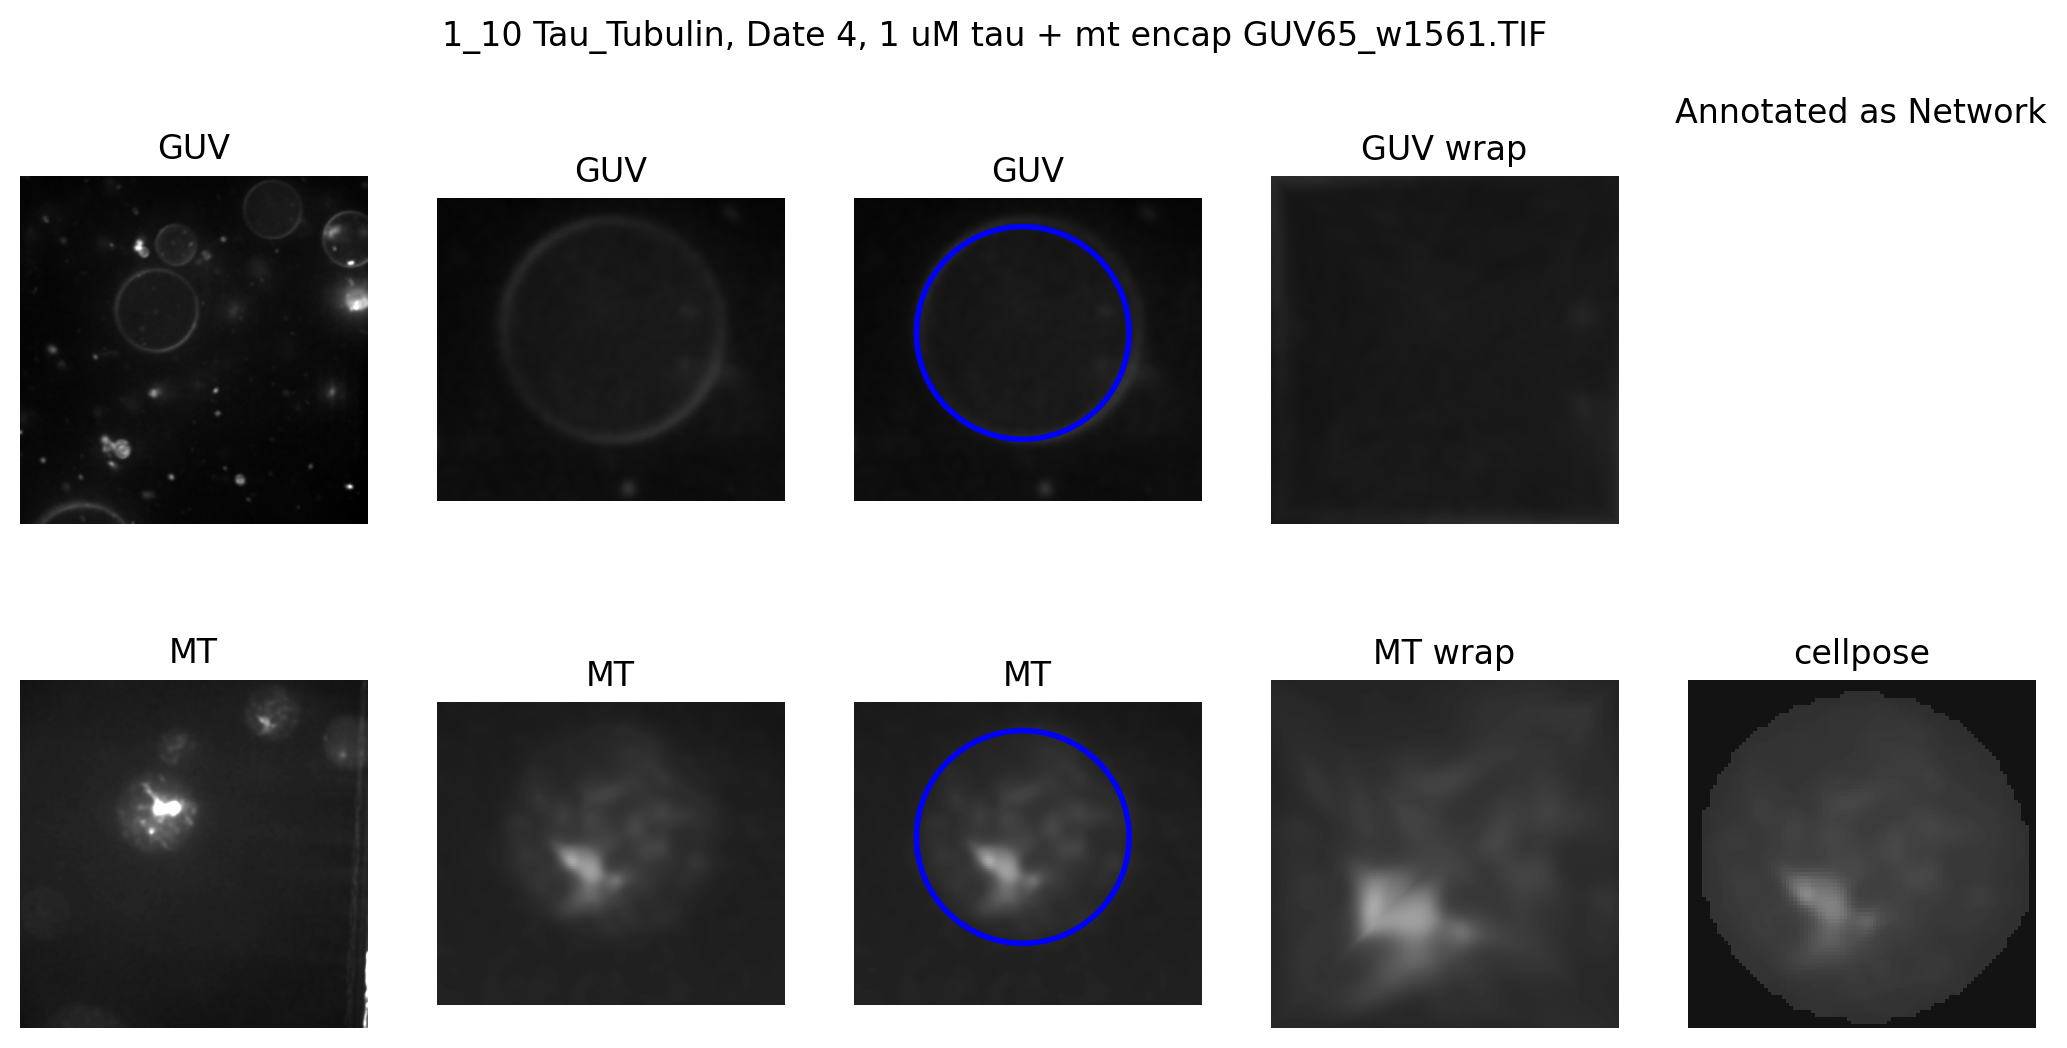

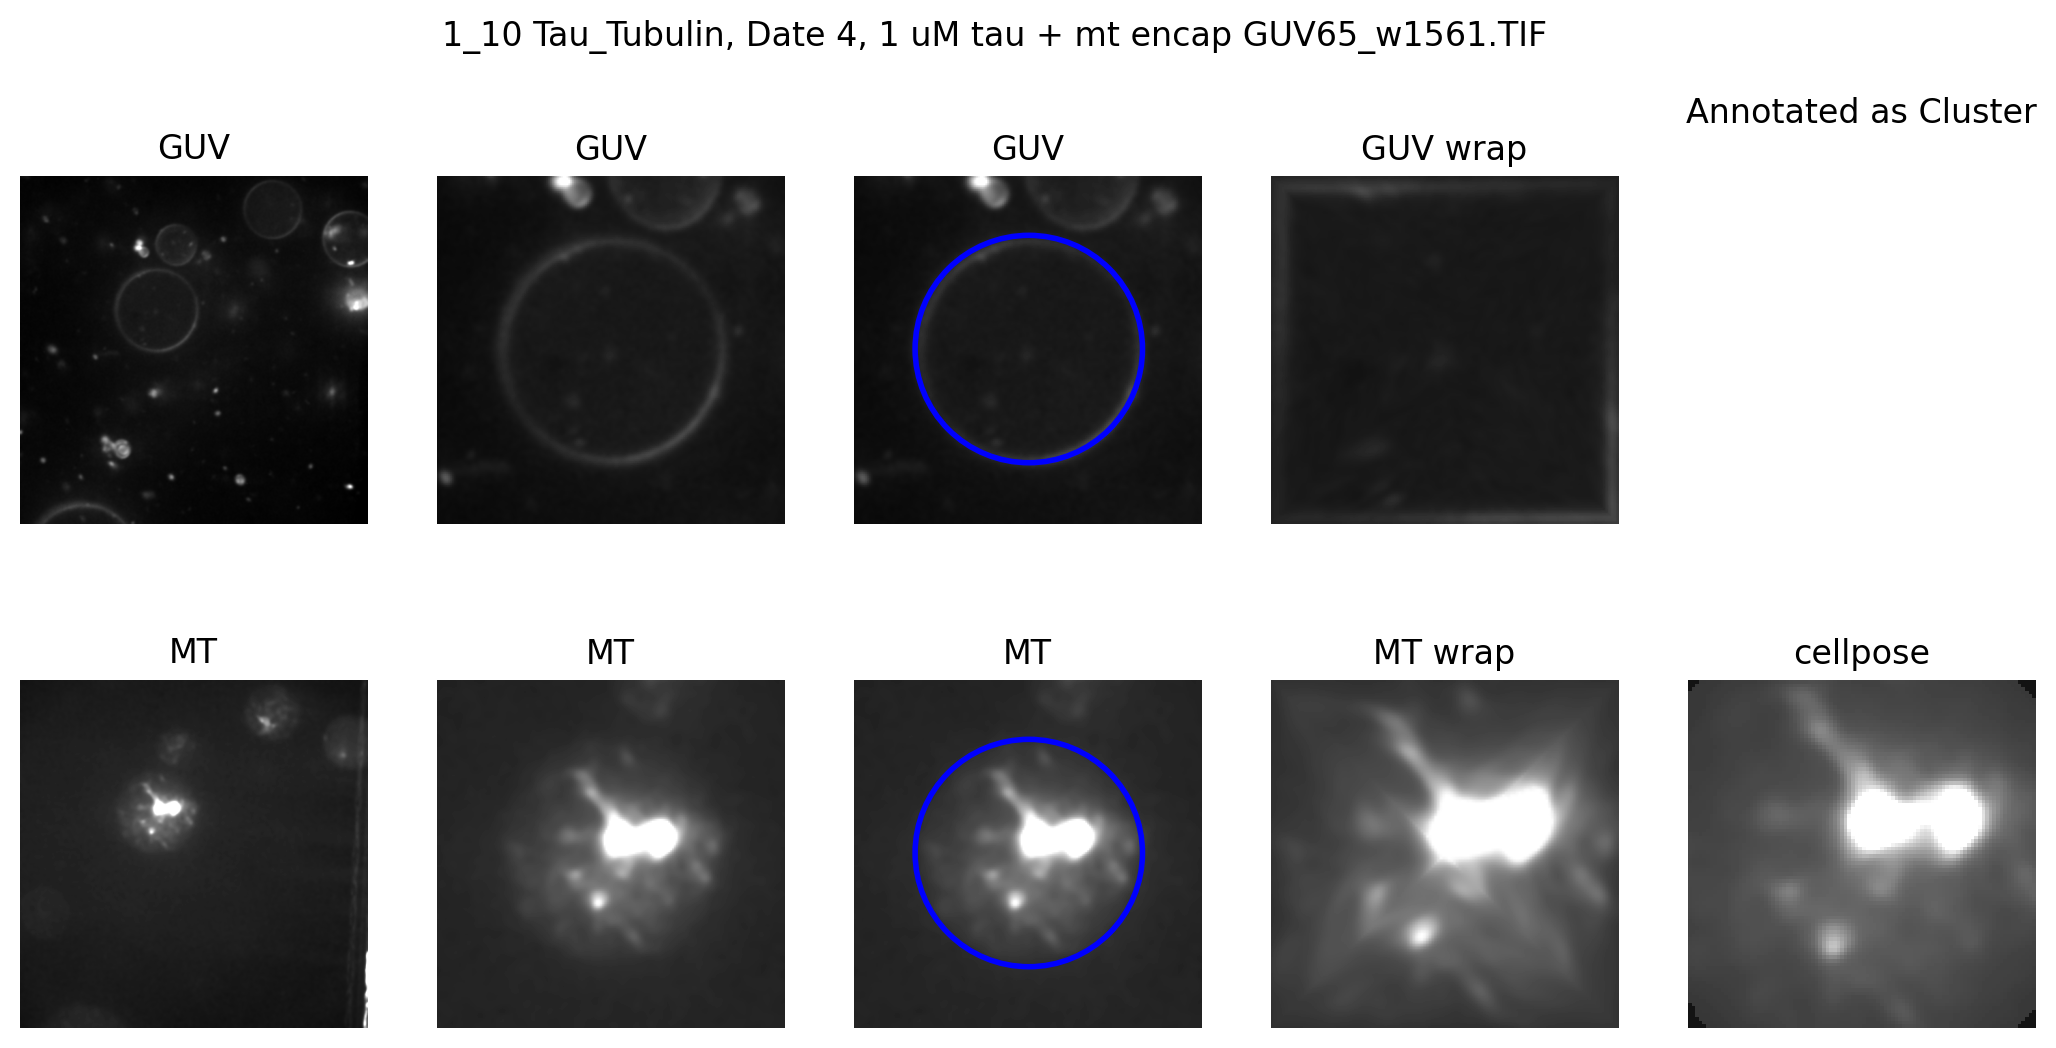

In [37]:
counts = 0

for index, row in annotation_csv.iterrows():
    # if index < 68 or index >71 :
    #     continue
    
    patch_tif_filename = row['Filename'].replace('.png', '.tif').replace("=", "")
    
    # Match in cellpose_results_csv
    matching_rows_batch1 = cellpose_results_csv[
        cellpose_results_csv['obj_filename']==patch_tif_filename    ]

    if not matching_rows_batch1.empty:
        obj_folder = matching_rows_batch1.iloc[0]['obj_folder']
        obj_filename =  matching_rows_batch1.iloc[0]['obj_filename']
        GUV_folder_path = matching_rows_batch1.iloc[0]['GUV_folder_path']
        GUV_file_name = matching_rows_batch1.iloc[0]['GUV_file_name']
        MT_folder_path  = matching_rows_batch1.iloc[0]['MT_folder_path']
        MT_file_name = matching_rows_batch1.iloc[0]['MT_file_name']
        condition = matching_rows_batch1.iloc[0]['condition']
        cx = matching_rows_batch1.iloc[0]['cx']
        cy = matching_rows_batch1.iloc[0]['cy']
        diameter = matching_rows_batch1.iloc[0]['diameter']
        date = matching_rows_batch1.iloc[0]['date']

        cell_ID = matching_rows_batch1.iloc[0]['cell_ID']
        cell_index = matching_rows_batch1.iloc[0]['cell_index']


        bbox_1  = matching_rows_batch1.iloc[0]['bbox_1']
        bbox_2  = matching_rows_batch1.iloc[0]['bbox_2']
        bbox_3  = matching_rows_batch1.iloc[0]['bbox_3']
        bbox_4  = matching_rows_batch1.iloc[0]['bbox_4']


        GUV_image = tifffile.imread(os.path.join(GUV_folder_path,GUV_file_name))
        MT_image = tifffile.imread(os.path.join(MT_folder_path,MT_file_name))
        cellpose_crop_MT_image = tifffile.imread(os.path.join(obj_folder,obj_filename))

        if GUV_image.ndim ==3:
            GUV_image = GUV_image.max(axis=0).squeeze()
        if MT_image.ndim ==3:
            MT_image = MT_image.max(axis=0).squeeze()

        cx_min = max(0, int(cx - diameter/2*1.5))
        cx_max = min(int(cx + diameter/2*1.5), GUV_image.shape[0]-1)
        cy_min = max(0, int(cy - diameter/2*1.5))
        cy_max = min(int(cy + diameter/2*1.5), GUV_image.shape[1]-1)

        mt_img_medianfiltered = median(MT_image, disk(3))
        mt_img_medianfiltered_smooth = gaussian(mt_img_medianfiltered, sigma, preserve_range=True)
        mt_img_normed = (mt_img_medianfiltered_smooth - mt_1p)/(mt_99p - mt_1p)
        mt_img_normed[mt_img_normed<0] = 0
        mt_img_normed[mt_img_normed>1] = 1

        guv_smooth = gaussian(GUV_image, sigma, preserve_range=True)
        guv_img_normed = (guv_smooth - guv_1p)/(guv_99p - guv_1p)
        guv_img_normed[guv_img_normed<0] = 0
        guv_img_normed[guv_img_normed>1] = 1    
        from scipy.ndimage import gaussian_filter

        # blur1 = gaussian_filter(guv_img_normed, sigma=1)
        # blur2 = gaussian_filter(guv_img_normed, sigma=3)
        # dog = blur1 - blur2
        # dog[dog<0]=0
        # dog = dog/(0.25)
                
        GUV_image_crop =  guv_img_normed[cx_min:cx_max, cy_min:cy_max]
        MT_image_crop =  mt_img_normed[cx_min:cx_max, cy_min:cy_max]

        fig, ax = plt.subplots(2, 5, figsize=(13, 6),dpi=200)
        # plt.tight_layout()
        fig.suptitle(condition+', '+date+', '+ GUV_file_name)
        ax[0,0].imshow(guv_img_normed, clim=(0,1), cmap='gray')    
        ax[0,0].axis('off')
        ax[0,0].set_title('GUV')
        ax[1,0].imshow(mt_img_normed, clim=(0,1), cmap='gray')    
        ax[1,0].axis('off')
        ax[1,0].set_title('MT')

        ax[0,1].imshow(GUV_image_crop, clim=(0,1), cmap='gray')  
        ax[0,1].axis('off')
        ax[0,1].set_title('GUV')
        
        ax[1,1].imshow(MT_image_crop, clim=(0,1), cmap='gray')    
        ax[1,1].axis('off')
        ax[1,1].set_title('MT')


        GUV_image_crop_HOUGH = cv2.normalize(GUV_image_crop*255, None, 0, 255, cv2.NORM_MINMAX)
        GUV_image_crop_HOUGH = np.uint8(GUV_image_crop_HOUGH)

        circles = cv2.HoughCircles(
                GUV_image_crop_HOUGH, cv2.HOUGH_GRADIENT, dp=1.2, minDist=50, param1=15, param2=int(diameter/2*1.1), minRadius=int(diameter/2*0.7), maxRadius=int(diameter/2*1.1)
            )
        
        if circles is None or len(circles) == 0:
            print("empty: " +patch_tif_filename)
            fig.savefig(os.path.join(annotated_circle_square_panel_folder, condition+'-'+date+'-'+GUV_file_name+'_circle_filter.png'))
            plt.close(fig) 
            continue
          
        ax[0,2].imshow(GUV_image_crop, clim=(0,1), cmap='gray')  
        ax[0,2].axis('off')
        ax[0,2].set_title('GUV')
        plot_circle = plt.Circle((circles[0][0,0]+0, circles[0][0,1]+0), circles[0][0,2], fill=False, linewidth=2, color='blue')                      
        ax[0,2].add_patch(plot_circle)

        ax[1,2].imshow(MT_image_crop, clim=(0,1), cmap='gray')    
        ax[1,2].axis('off')
        ax[1,2].set_title('MT')

        plot_circle = plt.Circle((circles[0][0,0]+0, circles[0][0,1]+0), circles[0][0,2], fill=False, linewidth=2, color='blue')                      
        ax[1,2].add_patch(plot_circle)


        GUV_square_image = disk_to_square(GUV_image_crop.astype(np.float32), cx=circles[0][0,0]+0, cy=circles[0][0,1]+0, r=circles[0][0,2]*0.9999, output_size=128)
        ax[0,3].imshow(GUV_square_image, clim=(0,1), cmap='gray')    
        ax[0,3].axis('off')
        ax[0,3].set_title('GUV wrap')

        MT_square_image = disk_to_square(MT_image_crop.astype(np.float32), cx=circles[0][0,0]+0, cy=circles[0][0,1]+0, r=circles[0][0,2]*0.95, output_size=128)
        ax[1,3].imshow(MT_square_image, clim=(0,1), cmap='gray')    
        ax[1,3].axis('off')
        ax[1,3].set_title('MT wrap')

        
        ax[0,4].axis('off')
        category = str(row['Category']) if pd.notna(row['Category']) else "Unknown"
        ax[0, 4].set_title('Annotated as ' + category)
        
        ax[1,4].imshow(cellpose_crop_MT_image, clim=(0,1), cmap='gray')    
        ax[1,4].axis('off')
        ax[1,4].set_title('cellpose')


        display_image = MT_image_crop*255
        display_image[display_image>=255]=254

        obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex'+str(cell_index).zfill(4)+'.png'
        tifffile.imsave(os.path.join(annotated_circle_detection_png_folder, obj_filename),(display_image).astype(np.uint8))  
        
        obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex'+str(cell_index).zfill(4)+'.tif'
        tifffile.imwrite(os.path.join(annotated_circle_detection_tiff_folder, obj_filename),MT_image_crop.astype(np.float16))  
        
        obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex'+str(cell_index).zfill(4)+'.tif'
        tifffile.imwrite(os.path.join(annotated_circle_square_tiff_folder, obj_filename),MT_square_image.astype(np.float16))  
        
        fig.savefig(os.path.join(annotated_circle_square_panel_folder, condition+'-'+date+'-'+GUV_file_name+ '_cell'+str(cell_ID).zfill(2)+'_cellindex'+str(cell_index).zfill(4) +'_circle_filter.png'))
        # plt.close(fig) 
        counts = counts + 1



        # break      
        
       


In [35]:
counts

0

In [36]:
 

#         print(f"Labelled: cx: {cx:.1f}, cy: {cy:.1f}, diameter: {diameter:.1f}")

#         # Match in circle_results_csv
#         matching_rows_batch2 = circle_results_csv[
#             circle_results_csv['GUV_file_name'].str.contains(guv_name, na=False)
#         ]

#         if not matching_rows_batch2.empty:
#             matching_rows_batch2 = matching_rows_batch2[
#                 matching_rows_batch2['MT_file_name'].str.contains(mt_name, na=False)
#             ]
#             if not matching_rows_batch2.empty:
#                 matching_rows_batch2 = matching_rows_batch2[
#                     matching_rows_batch2['condition'].str.contains(condition, na=False)
#                 ]

#                 circle_cx_array = matching_rows_batch2['cx'].to_numpy()
#                 circle_cy_array = matching_rows_batch2['cy'].to_numpy()
#                 circle_radius_array = matching_rows_batch2['rarius'].to_numpy()
                           
#                 # print(matching_rows_batch2[['cx','cy','rarius']])


#                 difference = np.power(circle_cx_array-cy, 2) +np.power(circle_cy_array-cx,2) +np.power((circle_radius_array*2-diameter)/4,2)
                
#                 if(difference.min() < 100):
#                     index_match = np.argmin(difference)
#                     circle_cx = circle_cx_array[index_match]
#                     circle_cy = circle_cy_array[index_match]
#                     circle_radius = circle_radius_array[index_match]
#                     print(f"Matched:  cx: {circle_cy:.1f}, cy: {circle_cx:.1f}, radius*2: {circle_radius*2:.1f}, different: {difference.min():.1f}")
#                     counts = counts +1 
#                     # print([circle_cx,circle_cy,circle_radius])

#     # break  # Optional: uncomment to process only first row

# print(counts)